#1. Loading the Taxis Dataset

In [28]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [29]:
#Load the 'taxis' dataset
df = sns.load_dataset("taxis")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [30]:
df.dtypes

,0
pickup,datetime64[ns]
dropoff,datetime64[ns]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,object
payment,object


In [31]:
df.shape

(6433, 14)

#2. Handling Missing Values

In [32]:
# Check for missing values
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [33]:
# Impute missing values
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


In [34]:
# remove rows with missing values

Critical_col = ['pickup_zone', 'pickup_borough', 'dropoff_zone', 'dropoff_borough']
df = df.dropna(subset=Critical_col)

In [35]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


# 3. Visualizations using Matplotlib/Pandas Plot

In [36]:
# converted to a datetime
df['pickup'] = pd.to_datetime(df['pickup'])
df.dtypes

,0
pickup,datetime64[ns]
dropoff,datetime64[ns]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,object
payment,object


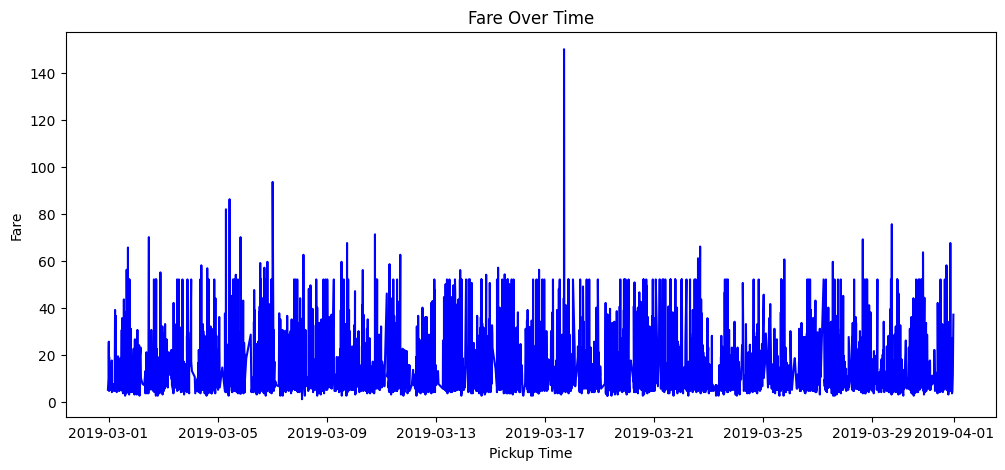

In [37]:
#1. Line Chart
df = df.sort_values('pickup')
plt.figure(figsize=(12, 5))
plt.plot(df['pickup'], df['fare'], color='blue')
plt.title('Fare Over Time')
plt.xlabel('Pickup Time')
plt.ylabel('Fare')

plt.show()

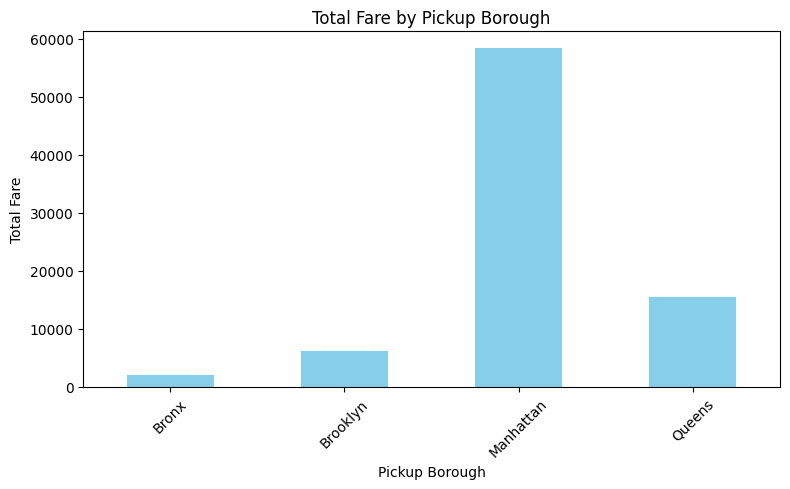

In [38]:
#2. Bar Chart
borough_fare = df.groupby('pickup_borough')['fare'].sum()
plt.figure(figsize=(8, 5))
borough_fare.plot(kind='bar', color='skyblue')
plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


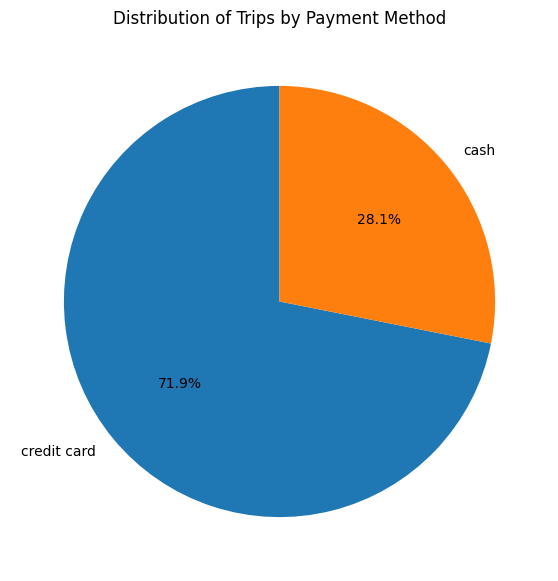

In [39]:
#3. Pie Chart
payment_counts = df['payment'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Trips by Payment Method')
plt.show()

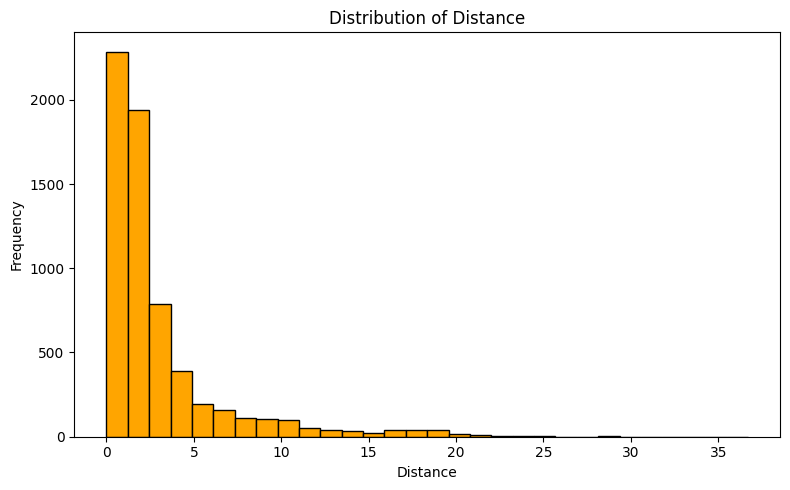

In [40]:
#4. Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['distance'], bins=30, color='orange', edgecolor='black')
plt.title('Distribution of Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

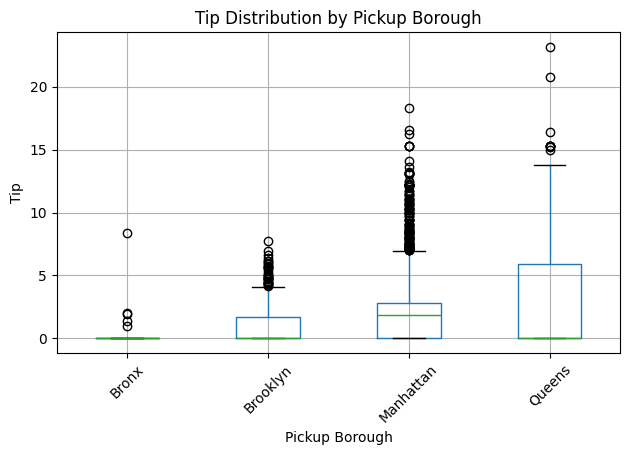

In [41]:
#5. Box Plot
plt.figure(figsize=(10, 5))
df.boxplot(column='tip', by='pickup_borough')
plt.title('Tip Distribution by Pickup Borough')
plt.suptitle('')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Visualizations using Seaborn

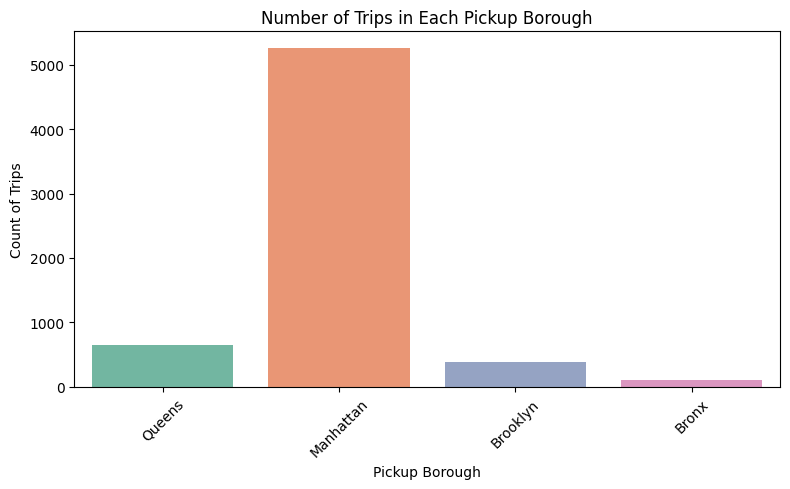

In [42]:
#1. Count Plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pickup_borough', palette='Set2')
plt.title('Number of Trips in Each Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Count of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

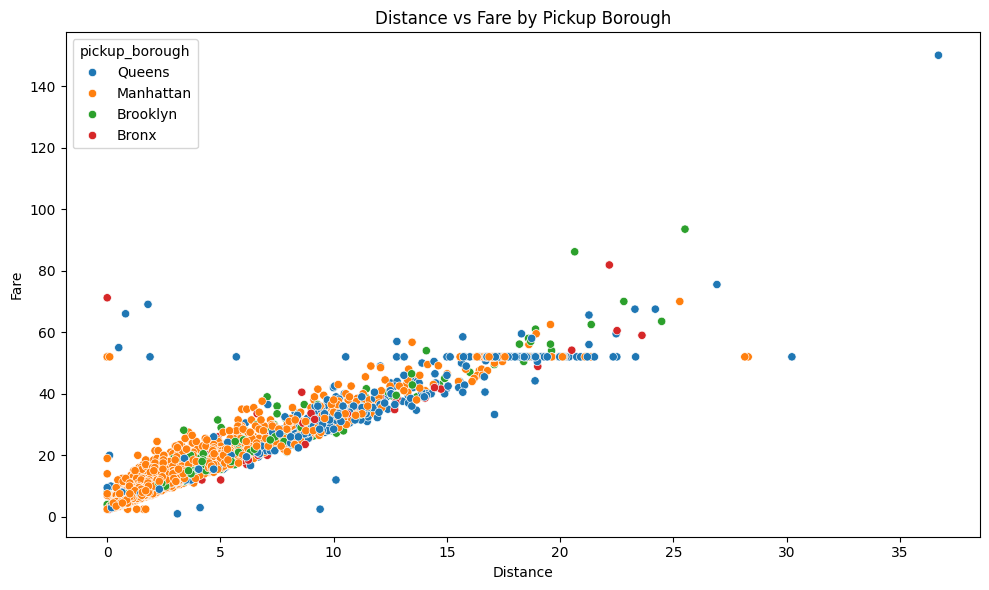

In [43]:
#2. Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance', y='fare', hue='pickup_borough')
plt.title('Distance vs Fare by Pickup Borough')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()


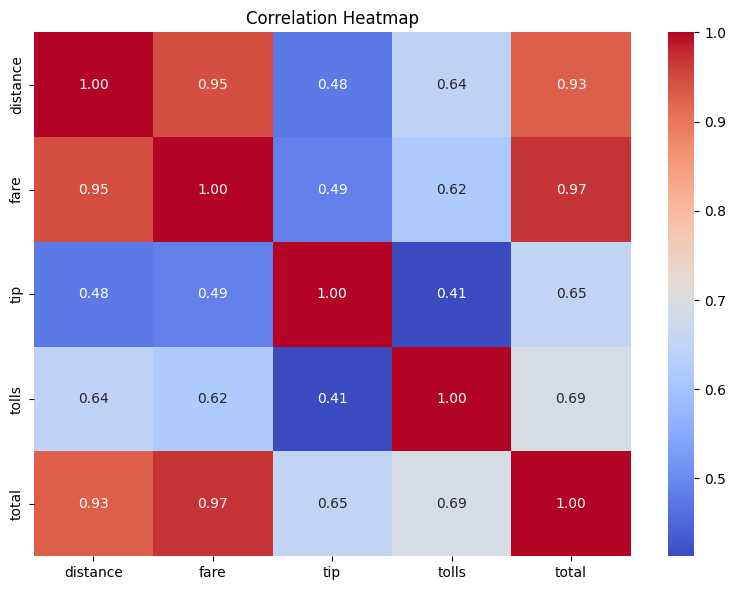

In [44]:
#3. Heatmap
corr_data = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

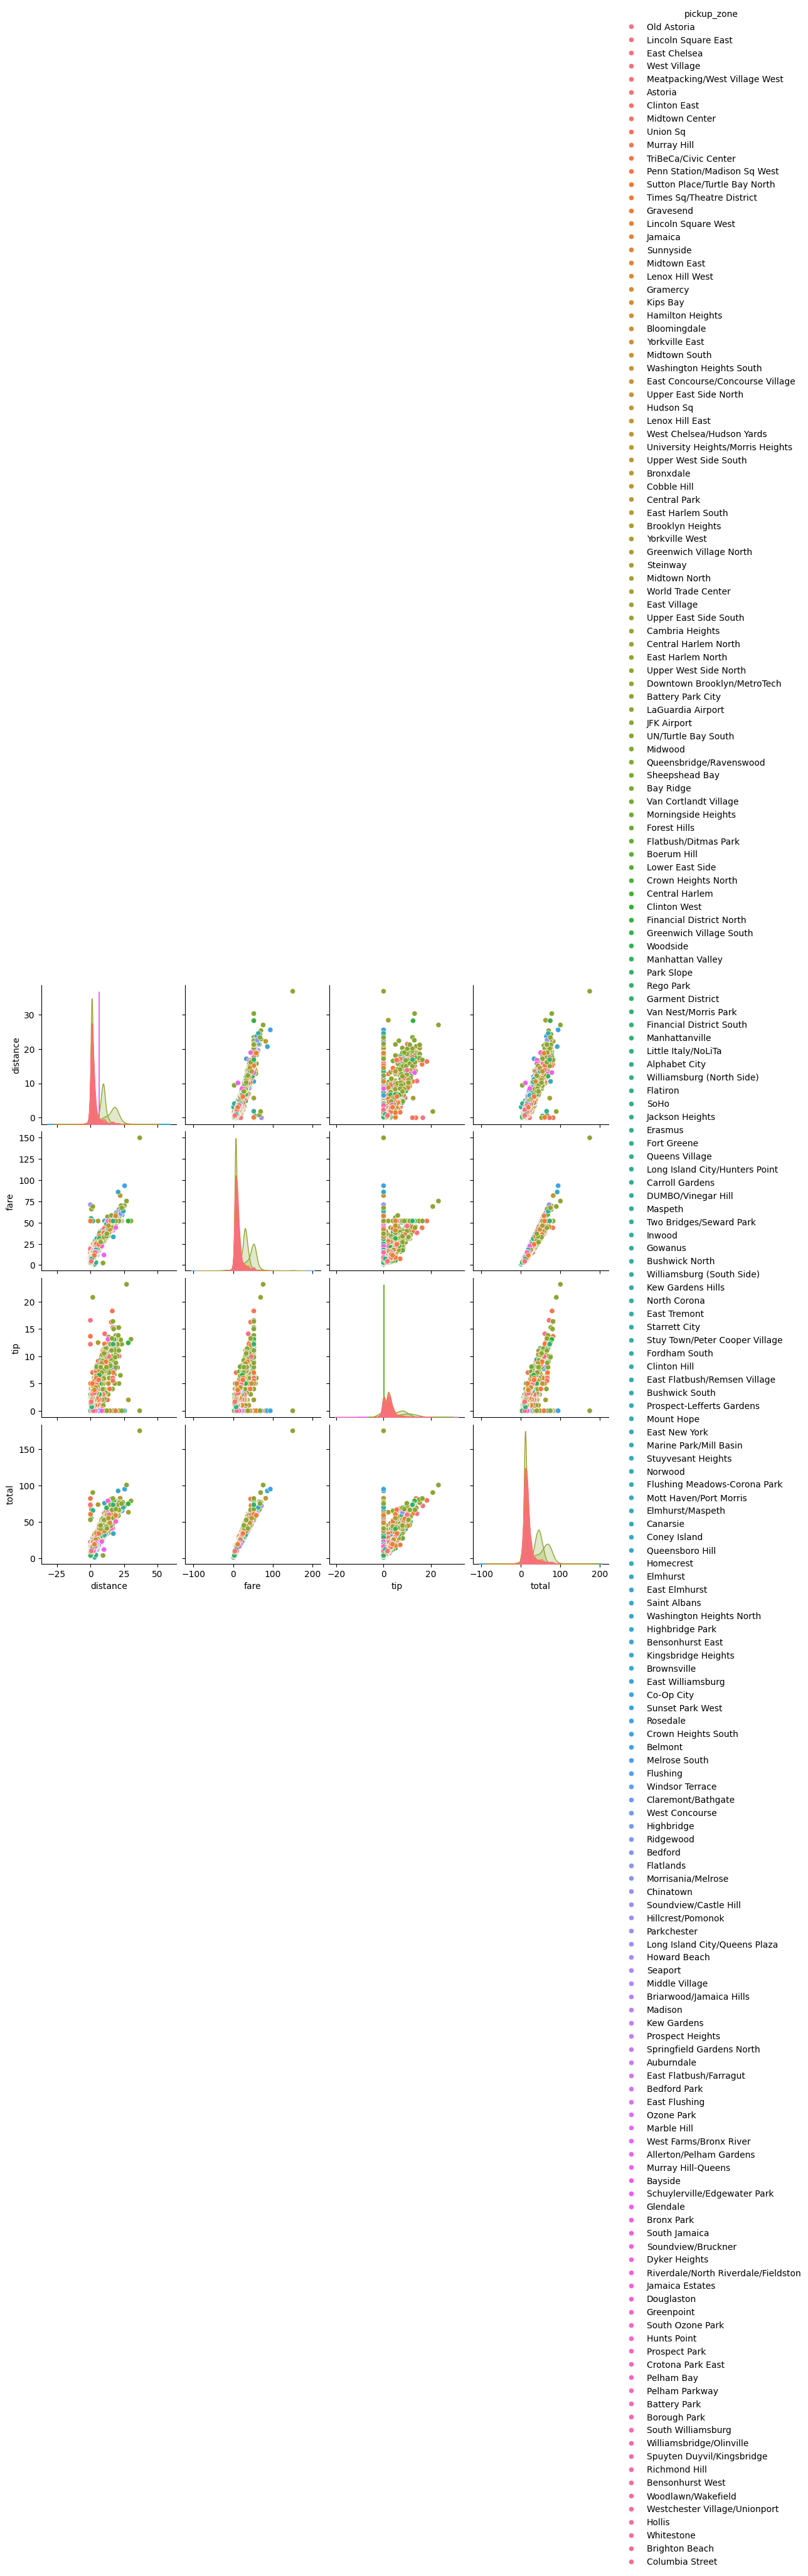

In [45]:
#4. Pair Plot
pair_df = df[['distance', 'fare', 'tip', 'total', 'pickup_zone']].dropna()
sns.pairplot(pair_df, hue='pickup_zone')
plt.show()

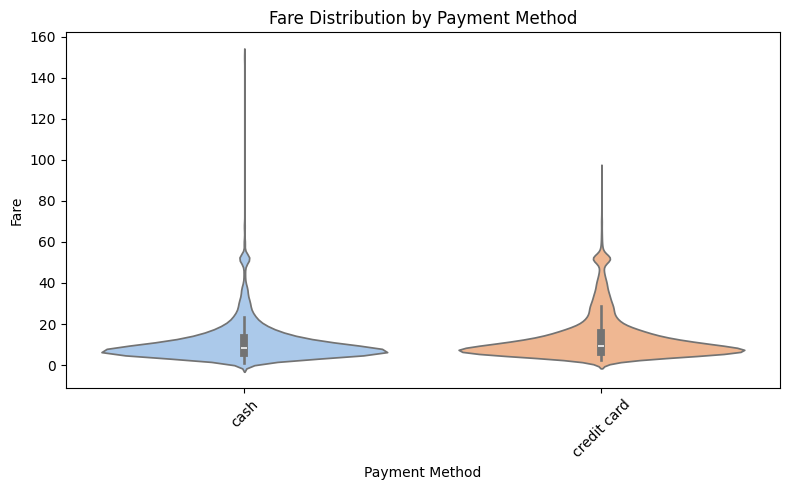

In [46]:
#5. Violin Plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='payment', y='fare', palette='pastel')
plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()